<a href="https://colab.research.google.com/github/mar25-iia2-radiographies/02_modelisation/blob/main/03_radiographie_covid_classification_CNN_Custom_TF_Keras_Houssein_fixed_splits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification des radiographies pulmonaires COVID-19 — CNN custom TensorFlow / Keras (splits CSV figés)

Ce notebook reprend la continuité des notebooks précédents, mais **le split train / validation / test n'est plus généré ici**.

À la place, on lit directement les fichiers :

- `dataset_splits/train_df.csv`
- `dataset_splits/val_df.csv`
- `dataset_splits/test_df.csv`

## Pourquoi cette version

Pour comparer proprement plusieurs modèles (**Dense**, **CNN custom**, **EfficientNetB0**, etc.), il faut utiliser **exactement le même split**.  
Ainsi, les différences observées viennent du modèle, pas d'un nouveau tirage aléatoire.

## Ce notebook fait

- lecture des splits CSV
- résolution robuste des chemins images / masques
- prétraitement cohérent avec les anciens notebooks :
  - grayscale
  - masque pulmonaire optionnel
  - resize `128x128`
  - CLAHE optionnel
  - normalisation `[0, 1]`
- `tf.data` pour charger les images **à la volée** (plus économe en RAM)
- CNN custom largement commenté
- data augmentation activable / désactivable avec un simple booléen
- `class_weight`
- courbes train / validation
- `classification_report`
- matrice de confusion
- tableau des métriques par classe

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# =========================
# Installation (Google Colab)
# =========================
# TensorFlow est généralement déjà disponible dans Colab.
# On installe ici uniquement les bibliothèques utiles autour du pipeline.

!pip -q install kagglehub opencv-python scikit-learn seaborn

In [ ]:

# =========================
# Imports et environnement
# =========================

import os
import gc
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print("TensorFlow version :", tf.__version__)
print("GPU disponible     :", tf.config.list_physical_devices("GPU"))

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.20.0
GPU disponible     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:

# =========================
# Configuration générale
# =========================
# Toute la configuration importante est centralisée ici.
# Tu peux modifier cette cellule sans toucher au reste du notebook.

# -------------------------
# Split CSV
# -------------------------
# Les trois CSV sont attendus dans un dossier dataset_splits.
# Le notebook cherchera automatiquement ce dossier dans plusieurs endroits.
SPLITS_DIR_CANDIDATES = [
    Path("/content/drive/MyDrive/Colab Notebooks/dataset_splits"),
    Path("dataset_splits"),
    Path("/kaggle/working/dataset_splits"),
    Path("."),
]

TRAIN_CSV_NAME = "train_df.csv"
VAL_CSV_NAME   = "val_df.csv"
TEST_CSV_NAME  = "test_df.csv"

# -------------------------
# Classes / labels
# -------------------------
# On garde le même ordre de classes dans tous les notebooks.
CATEGORIES = ["COVID", "Normal", "Lung_Opacity", "Viral Pneumonia"]
NUM_CLASSES = len(CATEGORIES)
CLASS_TO_ID = {label: idx for idx, label in enumerate(CATEGORIES)}
ID_TO_CLASS = {idx: label for label, idx in CLASS_TO_ID.items()}

# -------------------------
# Prétraitement images
# -------------------------
TARGET_SIZE = 128
N_CHANNELS = 1

APPLY_MASK = True
APPLY_CLAHE = True

CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_SIZE = (8, 8)

# -------------------------
# tf.data / batch
# -------------------------
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DATASET = False   # Laisser False si la RAM Colab est juste

# -------------------------
# Data augmentation
# -------------------------
USE_AUGMENTATION = True

AUG_ROTATION = 0.05
AUG_TRANSLATION = 0.03
AUG_ZOOM = 0.05
AUG_CONTRAST = 0.08

# -------------------------
# Entraînement
# -------------------------
EPOCHS = 20
LEARNING_RATE = 1e-3
USE_CLASS_WEIGHTS = True

## Stratégie de split utilisée ici

Les fichiers CSV fournis deviennent la **source de vérité** pour les splits.

Cela veut dire :

- **train** : utilisé pour apprendre les poids du modèle
- **validation** : utilisé pour suivre `val_loss`, ajuster le learning rate et déclencher l'early stopping
- **test** : utilisé **une seule fois** à la fin, pour mesurer la performance finale

Cette stratégie garantit une comparaison juste entre plusieurs architectures.

In [ ]:

# =========================
# Localisation robuste du dossier contenant les CSV de split
# =========================

def find_splits_dir(candidates, train_name, val_name, test_name):
    '''
    Cherche le dossier contenant les 3 CSV de split.
    On autorise plusieurs emplacements possibles pour rendre le notebook
    robuste sur Colab / Kaggle / exécution locale.
    '''
    for candidate in candidates:
        if (candidate / train_name).exists() and (candidate / val_name).exists() and (candidate / test_name).exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Impossible de trouver le dossier dataset_splits contenant "
        f"{train_name}, {val_name}, {test_name}."
    )

splits_dir = find_splits_dir(SPLITS_DIR_CANDIDATES, TRAIN_CSV_NAME, VAL_CSV_NAME, TEST_CSV_NAME)
print("Dossier des splits détecté :", splits_dir)

train_df = pd.read_csv(splits_dir / TRAIN_CSV_NAME)
val_df   = pd.read_csv(splits_dir / VAL_CSV_NAME)
test_df  = pd.read_csv(splits_dir / TEST_CSV_NAME)

print("train_df :", train_df.shape)
print("val_df   :", val_df.shape)
print("test_df  :", test_df.shape)

display(train_df.head())

Dossier des splits détecté : /content/drive/MyDrive/Colab Notebooks/dataset_splits
train_df : (14815, 3)
val_df   : (3175, 3)
test_df  : (3175, 3)


,label,image_path,mask_path
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...


In [ ]:

# =========================
# Téléchargement / localisation du dataset Kaggle
# =========================
# On reste cohérent avec les notebooks précédents.
# kagglehub télécharge (ou retrouve dans le cache) le dataset Kaggle.

import kagglehub

data_path = Path(kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database"))
print("Dataset téléchargé / localisé dans :", data_path)

Using Colab cache for faster access to the 'covid19-radiography-database' dataset.
Dataset téléchargé / localisé dans : /kaggle/input/covid19-radiography-database


In [ ]:

# =========================
# Résolution robuste de la racine réelle du dataset
# =========================

def resolve_dataset_root(base_path: Path, categories):
    '''
    Trouve automatiquement le vrai dossier racine contenant les classes.

    Cas gérés :
    1) base_path / "COVID-19_Radiography_Dataset" / <classe>
    2) base_path / <classe>
    3) recherche récursive d'un dossier contenant toutes les classes
    '''
    candidate_1 = base_path / "COVID-19_Radiography_Dataset"
    if candidate_1.exists() and all((candidate_1 / cat).exists() for cat in categories):
        return candidate_1

    if all((base_path / cat).exists() for cat in categories):
        return base_path

    for path in base_path.rglob("*"):
        if path.is_dir() and all((path / cat).exists() for cat in categories):
            return path

    raise FileNotFoundError("Impossible de trouver la racine réelle du dataset.")

dataset_root = resolve_dataset_root(data_path, CATEGORIES)
print("dataset_root =", dataset_root)

dataset_root = /kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset


In [ ]:

# =========================
# Remapping robuste des chemins CSV -> chemins locaux Colab
# =========================
# Les CSV ont été générés dans un autre environnement (chemins de type /kaggle/input/...).
# Ici, on reconstruit automatiquement les chemins locaux correspondants.

def remap_csv_path_to_local(original_path: str, label: str, kind: str, dataset_root: Path):
    '''
    Convertit un chemin stocké dans les CSV vers le vrai chemin local.

    kind : "images" ou "masks"

    Stratégie :
    1) si le chemin existe déjà tel quel -> on le garde
    2) si le chemin contient "COVID-19_Radiography_Dataset", on récupère le suffixe
       et on le recolle à la racine locale
    3) sinon, on reconstruit depuis : dataset_root / label / kind / basename
    '''
    p = Path(str(original_path))
    if p.exists():
        return p

    original_str = str(original_path)
    marker = "COVID-19_Radiography_Dataset"
    if marker in original_str:
        suffix = original_str.split(marker, 1)[1].lstrip("/\\")
        candidate = dataset_root / suffix
        if candidate.exists():
            return candidate

    basename = Path(original_path).name
    candidate = dataset_root / label / kind / basename
    return candidate

def prepare_split_df(df, dataset_root, class_to_id):
    '''
    Prépare un split :
    - remap des chemins image / masque
    - encodage des labels
    - vérification d'existence
    '''
    out = df.copy()

    out["image_path_local"] = [
        str(remap_csv_path_to_local(img, label, "images", dataset_root))
        for img, label in zip(out["image_path"], out["label"])
    ]
    out["mask_path_local"] = [
        str(remap_csv_path_to_local(mask, label, "masks", dataset_root))
        for mask, label in zip(out["mask_path"], out["label"])
    ]
    out["label_id"] = out["label"].map(class_to_id)

    missing_images = out[~out["image_path_local"].map(lambda x: Path(x).exists())]
    missing_masks = out[~out["mask_path_local"].map(lambda x: Path(x).exists())]

    if len(missing_images) > 0:
        print("Attention : images manquantes :", len(missing_images))
        display(missing_images.head())

    if len(missing_masks) > 0:
        print("Attention : masques manquants :", len(missing_masks))
        display(missing_masks.head())

    if out["label_id"].isna().any():
        unknown = out[out["label_id"].isna()]["label"].unique()
        raise ValueError(f"Labels inconnus détectés : {unknown}")

    out["label_id"] = out["label_id"].astype(np.int32)
    return out

train_df = prepare_split_df(train_df, dataset_root, CLASS_TO_ID)
val_df   = prepare_split_df(val_df, dataset_root, CLASS_TO_ID)
test_df  = prepare_split_df(test_df, dataset_root, CLASS_TO_ID)

print("Préparation des splits terminée.")
display(train_df.head())

Préparation des splits terminée.


,label,image_path,mask_path,image_path_local,mask_path_local,label_id
0,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,0
1,Lung_Opacity,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,2
2,Viral Pneumonia,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,3
3,Normal,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,1
4,COVID,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,/kaggle/input/covid19-radiography-database/COV...,0


,split,class_name,count
0,train,COVID,2531
1,train,Normal,7134
2,train,Lung_Opacity,4208
3,train,Viral Pneumonia,942
4,validation,COVID,543
5,validation,Normal,1529
6,validation,Lung_Opacity,902
7,validation,Viral Pneumonia,201
8,test,COVID,542
9,test,Normal,1529


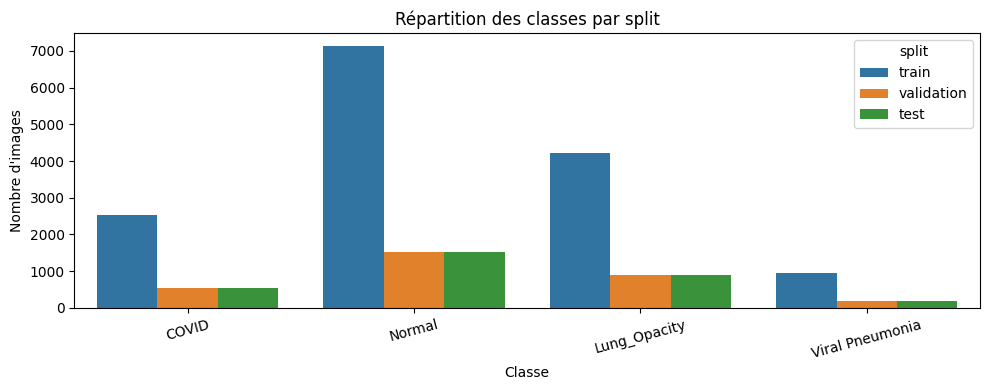

In [ ]:

# =========================
# Répartition des classes par split
# =========================

def make_split_distribution(df, split_name):
    counts = df["label"].value_counts().reindex(CATEGORIES)
    return pd.DataFrame({
        "split": split_name,
        "class_name": CATEGORIES,
        "count": counts.values
    })

split_dist_df = pd.concat([
    make_split_distribution(train_df, "train"),
    make_split_distribution(val_df, "validation"),
    make_split_distribution(test_df, "test"),
], ignore_index=True)

display(split_dist_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=split_dist_df, x="class_name", y="count", hue="split")
plt.title("Répartition des classes par split")
plt.xlabel("Classe")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

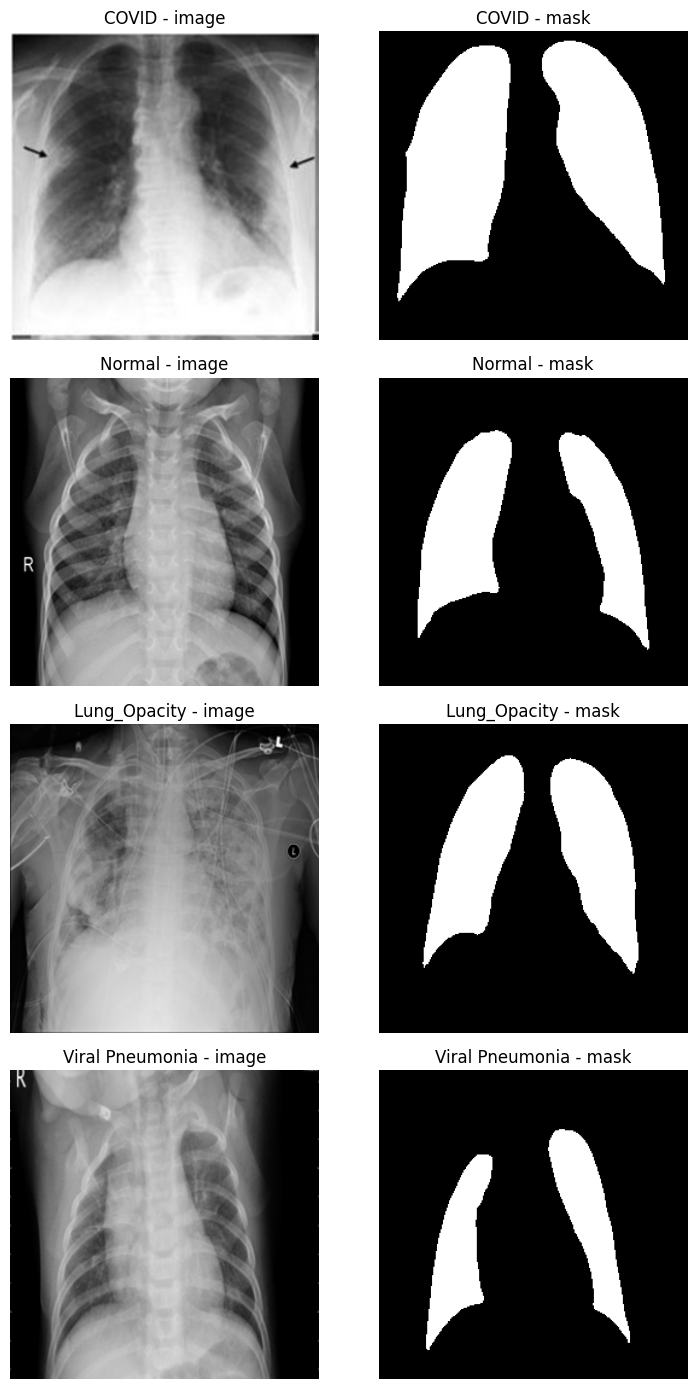

In [ ]:

# =========================
# Vérification visuelle rapide
# =========================
# On affiche quelques exemples après remapping des chemins.

fig, axes = plt.subplots(4, 2, figsize=(8, 14))

for i, category in enumerate(CATEGORIES):
    row = train_df[train_df["label"] == category].iloc[0]

    img = cv2.imread(row["image_path_local"], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(row["mask_path_local"], cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"{category} - image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{category} - mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Prétraitement `on-the-fly` avec `tf.data`

Ici, on **ne charge plus tout le dataset en RAM** comme dans le notebook précédent.

On utilise les chemins contenus dans les CSV, puis :
- lecture de l'image et du masque
- application éventuelle du masque pulmonaire
- resize
- CLAHE optionnel
- normalisation
- ajout du canal final `(H, W, 1)`

Cette stratégie est **plus robuste en mémoire** et convient mieux à Colab.

In [ ]:

# =========================
# Fonctions de prétraitement
# =========================

clahe = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_TILE_SIZE
)

def preprocess_image_with_mask_numpy(image_path, mask_path):
    '''
    Fonction de prétraitement exécutée côté Python / NumPy / OpenCV.
    Elle sera appelée depuis tf.data via tf.numpy_function.

    Sortie :
    - image float32 de forme (TARGET_SIZE, TARGET_SIZE, 1)
    '''
    image_path = image_path.decode("utf-8")
    mask_path = mask_path.decode("utf-8")

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")

    mask = None
    if APPLY_MASK and Path(mask_path).exists():
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if APPLY_MASK and mask is not None:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 0).astype(np.uint8)
        img = img * mask

    img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_AREA)

    if APPLY_CLAHE:
        img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)  # (H, W) -> (H, W, 1)
    return img

def tf_preprocess(image_path, mask_path, label):
    '''
    Wrapper TensorFlow autour de la fonction NumPy.
    On fixe explicitement la shape pour que Keras sache
    ce qui entre dans le réseau.
    '''
    image = tf.numpy_function(
        func=preprocess_image_with_mask_numpy,
        inp=[image_path, mask_path],
        Tout=tf.float32
    )
    image.set_shape((TARGET_SIZE, TARGET_SIZE, N_CHANNELS))
    label = tf.cast(label, tf.int32)
    return image, label

def make_dataset(df, training=False):
    '''
    Construit un tf.data.Dataset à partir d'un split DataFrame.
    '''
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path_local"].astype(str).values,
        df["mask_path_local"].astype(str).values,
        df["label_id"].values
    ))

    ds = ds.map(tf_preprocess, num_parallel_calls=AUTOTUNE)

    if CACHE_DATASET:
        ds = ds.cache()

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [ ]:

# =========================
# Class weights
# =========================
# Le dataset est déséquilibré.
# On calcule les poids de classes uniquement à partir du TRAIN.

classes = np.array(sorted(train_df["label_id"].unique()))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"].values
)

class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights_values)}
print("Class weights :", class_weight_dict)

Class weights : {0: 1.4633544053733702, 1: 0.5191687692738997, 2: 0.8801687262357415, 3: 3.9317940552016983}


In [ ]:

# =========================
# Pipelines tf.data
# =========================

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for batch_images, batch_labels in train_ds.take(1):
    print("Shape images batch :", batch_images.shape)
    print("Shape labels batch :", batch_labels.shape)

Shape images batch : (32, 128, 128, 1)
Shape labels batch : (32,)


In [ ]:

# =========================
# Bloc de data augmentation (optionnel)
# =========================
# Si USE_AUGMENTATION = False, ce bloc est simplement ignoré.
# Les transformations retenues sont volontairement modérées.

def build_augmentation_layer():
    return keras.Sequential(
        [
            layers.RandomRotation(AUG_ROTATION, seed=SEED),
            layers.RandomTranslation(AUG_TRANSLATION, AUG_TRANSLATION, seed=SEED),
            layers.RandomZoom(AUG_ZOOM, seed=SEED),
            layers.RandomContrast(AUG_CONTRAST, seed=SEED),
        ],
        name="data_augmentation"
    )

## Architecture du CNN custom

Architecture retenue :

- bloc 1 : `Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> MaxPool -> Dropout`
- bloc 2 : idem
- bloc 3 : idem
- bloc 4 : idem
- tête : `GlobalAveragePooling -> Dense -> Dropout -> Softmax`

Pourquoi ce choix :

- plus adapté aux images qu'un modèle dense
- plus riche qu'un LeNet classique
- reste raisonnable pour Colab
- moins de paramètres qu'une tête avec `Flatten`

In [ ]:

# =========================
# Définition du modèle CNN custom
# =========================

def conv_block(x, filters, dropout_rate, block_name):
    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False, name=f"{block_name}_conv1")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn1")(x)
    x = layers.ReLU(name=f"{block_name}_relu1")(x)

    x = layers.Conv2D(filters, (3, 3), padding="same", use_bias=False, name=f"{block_name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{block_name}_bn2")(x)
    x = layers.ReLU(name=f"{block_name}_relu2")(x)

    x = layers.MaxPooling2D((2, 2), name=f"{block_name}_pool")(x)
    x = layers.Dropout(dropout_rate, name=f"{block_name}_dropout")(x)
    return x

def build_custom_cnn(input_shape=(TARGET_SIZE, TARGET_SIZE, N_CHANNELS), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape, name="input_image")

    x = inputs

    if USE_AUGMENTATION:
        x = build_augmentation_layer()(x)

    x = conv_block(x, 32, 0.10, "block1")
    x = conv_block(x, 64, 0.15, "block2")
    x = conv_block(x, 128, 0.20, "block3")
    x = conv_block(x, 256, 0.25, "block4")

    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dense(128, activation="relu", name="dense_128")(x)
    x = layers.Dropout(0.30, name="head_dropout")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="custom_cnn_xray")
    return model

model = build_custom_cnn()
model.summary()

Model: "custom_cnn_xray"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 128, 128, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (ReLU)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 64, 64, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (ReLU)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 32, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (ReLU)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             

 Total params: 1,207,972 (4.61 MB)

 Trainable params: 1,206,052 (4.60 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:

# =========================
# Compilation du modèle
# =========================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:

# =========================
# Callbacks
# =========================

checkpoint_path = "best_custom_cnn_with_fixed_splits.keras"

callbacks_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:

# =========================
# Entraînement
# =========================

fit_kwargs = dict(
    x=train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

if USE_CLASS_WEIGHTS:
    fit_kwargs["class_weight"] = class_weight_dict

history = model.fit(**fit_kwargs)

Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5004 - loss: 1.0183
Epoch 1: val_loss improved from None to 1.08551, saving model to best_custom_cnn_with_fixed_splits.keras

Epoch 1: finished saving model to best_custom_cnn_with_fixed_splits.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 139s 157ms/step - accuracy: 0.5735 - loss: 0.8626 - val_accuracy: 0.5046 - val_loss: 1.0855 - learning_rate: 0.0010
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6687 - loss: 0.6870
Epoch 2: val_loss did not improve from 1.08551
463/463 ━━━━━━━━━━━━━━━━━━━━ 110s 126ms/step - accuracy: 0.6860 - loss: 0.6645 - val_accuracy: 0.5408 - val_loss: 2.0262 - learning_rate: 0.0010
Epoch 3/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7109 - loss: 0.6156
Epoch 3: val_loss improved from 1.08551 to 0.89936, saving model to best_custom_cnn_with_fixed_splits.keras

Epoch 3: finished saving model to best_custom_cnn_with_fixed_splits.keras
463/463 ━━━━━━━━━━━━━━━━━━━━ 110s 12

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.573540,0.862605,0.504567,1.085506,0.001
1,0.685994,0.664455,0.540787,2.026240,0.001
2,0.722848,0.602516,0.645984,0.899358,0.001
3,0.742221,0.573790,0.509921,1.395046,0.001
4,0.760041,0.546014,0.733858,0.716338,0.001


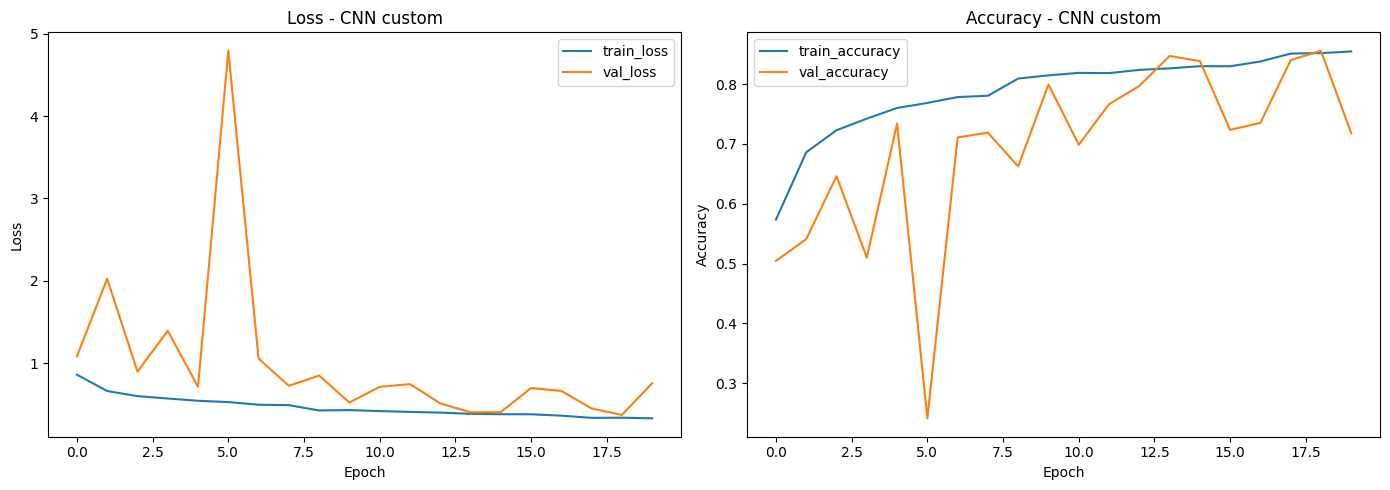

In [ ]:

# =========================
# Courbes d'apprentissage
# =========================

history_df = pd.DataFrame(history.history)
display(history_df.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="train_loss")
axes[0].plot(history.history["val_loss"], label="val_loss")
axes[0].set_title("Loss - CNN custom")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train_accuracy")
axes[1].plot(history.history["val_accuracy"], label="val_accuracy")
axes[1].set_title("Accuracy - CNN custom")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:

# =========================
# Évaluation sur le jeu de test
# =========================

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.4f}")

y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)
y_test = test_df["label_id"].values

report = classification_report(
    y_test,
    y_pred,
    target_names=CATEGORIES,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 240ms/step - accuracy: 0.8620 - loss: 0.3754
Test loss     : 0.3754
Test accuracy : 0.8620
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step


,precision,recall,f1-score,support
COVID,0.702492,0.832103,0.761824,542.000000
Normal,0.927436,0.877698,0.901882,1529.000000
Lung_Opacity,0.845982,0.840355,0.843159,902.000000
Viral Pneumonia,0.968421,0.910891,0.938776,202.000000
accuracy,0.861417,0.861417,0.861417,0.861417
macro avg,0.861083,0.865262,0.861410,3175.000000
weighted avg,0.868503,0.861417,0.863637,3175.000000


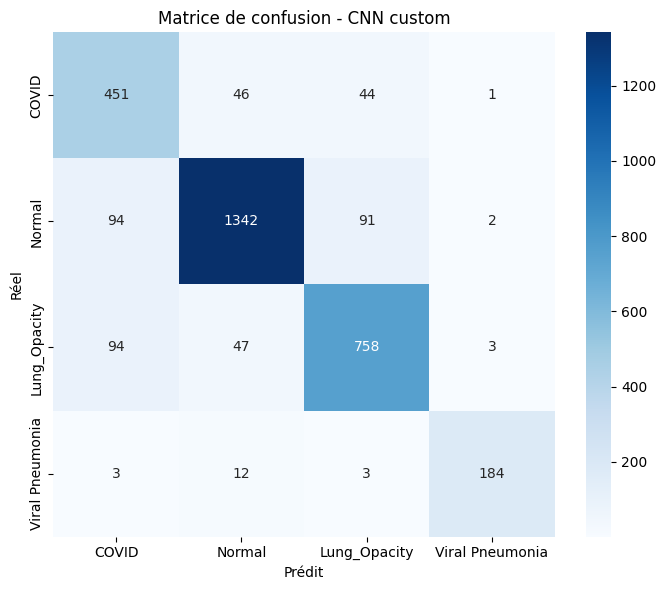

In [ ]:

# =========================
# Matrice de confusion
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CATEGORIES,
    yticklabels=CATEGORIES
)
plt.title("Matrice de confusion - CNN custom")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

In [ ]:

# =========================
# Tableau de métriques par classe
# =========================

per_class_df = report_df.loc[CATEGORIES, ["precision", "recall", "f1-score", "support"]].copy()
per_class_df = per_class_df.reset_index().rename(columns={"index": "class_name"})
display(per_class_df)

,class_name,precision,recall,f1-score,support
0,COVID,0.702492,0.832103,0.761824,542.0
1,Normal,0.927436,0.877698,0.901882,1529.0
2,Lung_Opacity,0.845982,0.840355,0.843159,902.0
3,Viral Pneumonia,0.968421,0.910891,0.938776,202.0


In [ ]:

# =========================
# Nettoyage mémoire (optionnel)
# =========================

gc.collect()

27133